## Veriyi Yükleme ve Hazırlama

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets as datasets

In [ ]:
iris = datasets.load_iris() # veri setini yükler
X = iris.data
y = iris.target

## Veri boyutunu anlamak

In [7]:
print("Orjinal veri boyutu:", X.shape)
print("Etiket veri boyutu:", y.shape)

Orjinal veri boyutu: (150, 4)
Etiket veri boyutu: (150,)


- PCA verinin yayılımını (varyansını) analiz eder bu analizin doğru olabilmesi için tüm veri setinin ağırlık merkezinin orjin noktasında olması gerekir

In [8]:
X_meaned = X - np.mean(X, axis=0) #verinin ağırlık merkezini orjin noktasına taşır 
# her sütunun ortlamasını (1x4 vektör) X'in her satırından çıkarır

## Veri Yapısını Hesaplamak (Kovaryans Matrisi)

In [ ]:
cov_matrix = np.cov(X_meaned.T) # Merkezileşmiş verinin üzerinden kovaryans matrisini heasağlama
# np.cov fonksiyonu her sütunu bir değişken olarak kabul eder bu yüzden transpozunu alıyoruz

print("Kovaryans matrisi boyutu\n", cov_matrix.shape)  

cov_matrix 

Kovaryans matrisi boyutu
 (4, 4)


array([[ 0.68569351, -0.042434  ,  1.27431544,  0.51627069],
       [-0.042434  ,  0.18997942, -0.32965638, -0.12163937],
       [ 1.27431544, -0.32965638,  3.11627785,  1.2956094 ],
       [ 0.51627069, -0.12163937,  1.2956094 ,  0.58100626]])

- cov_matrix.shape (4, 4) $\rightarrow$ "Toplam 4 bileşen var.", Amaç: en önemli 2 tanesini almak 


## ## Yeni Koordinat Sistemini Bulmak

In [15]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

print("Özdeğerler:\n", eigen_values,"\n")
print("Özvektörler matrisi boyutu:\n", eigen_vectors.shape)

Özdeğerler:
 [4.22824171 0.24267075 0.0782095  0.02383509] 

Özvektörler matrisi boyutu:
 (4, 4)


-  [4.22824171 0.24267075 0.0782095  0.02383509] özdeğerler her bir yeni eksenin ne kadar varyans taşıdığını gösteren önem puanlarıdır 
- özdeğerler yorum : orjinal 4 boyutlu verideki bilginin çoğu tek bir yerde [4.22824171] toplanmış 3. ve 4. bileşenler büyük olasılıkla gürültü taşımaktadır

- Özvektörler : bu matris yukardaki önem puanlarına karşılık gelen yönleri tanımlar. Bu matrisin her bir sütunu 4 boyutlu uzayda yeni bir baz vektörüdür

* kısaca buradaki amacımız   en çok bilgi içeren baz vektörlerini bulmak ve mevcut uzayı daha düşük bir uzaya indirgemektir 4->2

## Veriyi Yeni Baza Dönüştür (Lineer Dönüşüm)

In [16]:
projection_matrix = eigen_vectors[:, :2] # ilk 2 sütunu alacağız çünkü en büyük 2 özdeğere karşılık geliyorlar

# 150x4 veriyi, 4x2 matrisle çarparak 150x2'ye dönüştür
X_pca = X_meaned.dot(projection_matrix) # veriyi yeni bir uzaya yasıtma

## elde edilen 

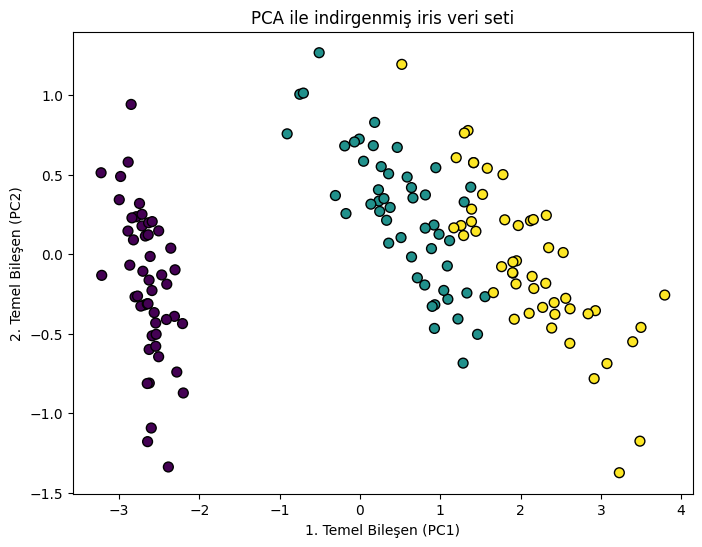

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolors='k', s=50)
plt.title('PCA ile indirgenmiş iris veri seti')
plt.xlabel('1. Temel Bileşen (PC1)')
plt.ylabel('2. Temel Bileşen (PC2)')
plt.show()

## Sonuç

- 1. Temel Bileşen (PC1 / X-Ekseni): Bu eksen bizim en büyük özdeğerimize karşılık gelen eksenimizdi grafiğe baktığımızda bu eksenin kümeleri ayırmak için nerdeyse yeterli olduğunu görebiliyoruz. Varyansın (ve ayrımın) çoğu bu eksende gerçekleşiyor

- 2. Temel Bileşen (PC2 / Y-Ekseni): Bu eksen ise 2. en büyük özdeğer karşılık gelen eksendi PC1 kadar bilgili olmasada sarı ve yeşil kümelerin birbirinden ayrılmasına yardımcı olan ikinci eksen olduğunu görüyoruz